**Proyecto Final: Optimización del Cierre Contable Detección Automatizada de Gastos Esporádicos mediante Modelos de Regresión**

**Introducción y Planteamiento del Problema**

En el área de control de costos, el cierre contable mensual requiere clasificar los egresos en gastos recurrentes (operación normal) y gastos esporádicos (eventos atípicos o imprevistos). Actualmente, este proceso se realiza de forma manual mediante revisiones fila por fila. Este enfoque tradicional presenta tres dificultades principales:
Subjetividad: Depende del criterio del analista que realiza la revisión.
Inconsistencia: No considera la estacionalidad ni la tendencia de crecimiento a largo plazo.
Eficiencia: Consume un tiempo operativo valioso que podría dedicarse al análisis estratégico.

**Propuesta con Enfoque de Machine Learning**

Para solucionar esto, implementaremos un modelo de Aprendizaje Supervisado utilizando el histórico de gastos de los años 2024, 2025 y lo que va de 2026. El modelo aprenderá el comportamiento normal de los costos para predecir un presupuesto estimado para el mes de cierre. Aquellos gastos reales que se desvíen de manera significativa de la predicción serán clasificados automáticamente como Gastos Esporádicos mediante el análisis estadístico de sus errores o residuos.

**Estructura de las Variables**

Variable Objetivo (Y): Monto neto mensual por grupo de gasto (NETO).
Variables Predictoras (X):
 - Gasto del mes anterior (t-1).
 - Gasto de hace dos meses (t-2).
 - Promedio móvil de los últimos meses (tendencia a corto plazo).
 - Mes del año (para capturar la estacionalidad).


# BLOQUE 1: Exploración, Consolidación y Limpieza de Datos (EDA)

In [20]:
# IMPORTACIÓN DE LIBRERIAS

# Librerías para manipular datos
import pandas as pd
import numpy as np
import os
import glob

# Librerías para realizar gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para dividir los datos
from sklearn.model_selection import train_test_split

# Librería para escalar las variables
from sklearn.preprocessing import StandardScaler

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas para evaluar los modelos
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

In [21]:
# CONSOLIDACIÓN Y LIMPIEZA (EDA)

# Ruta de la carpeta de trabajo
ruta_carpeta = r"C:\Users\lenovo\Desktop\BOOTCAMP DATA SCIENCE\Proyecto Final"

# Buscar todos los archivos de Excel en la carpeta
patron_archivos = os.path.join(ruta_carpeta, "*.xls*")
archivos_excel = glob.glob(patron_archivos)

lista_dataframes = []
columnas_interes = ['as_movano', 'as_movmes', 'GR', 'as_cuenom', 'NETO']

# Procesar y unificar los archivos
for archivo in archivos_excel:
    nombre_archivo = os.path.basename(archivo)
    
    # Evitar leer el archivo consolidado si ya existe de ejecuciones previas
    if "gastos_consolidados_limpios" in nombre_archivo:
        continue
        
    try:
        xl = pd.ExcelFile(archivo)
        pestanas = xl.sheet_names
        
        # Buscar la pestaña que contiene los movimientos o gastos
        pestana_a_cargar = pestanas[0]
        for p in pestanas:
            if "mov" in p.lower() or "gastos" in p.lower():
                pestana_a_cargar = p
                break
                
        df_temp = pd.read_excel(archivo, sheet_name=pestana_a_cargar)
        
        # Limpiar nombres de columnas y filtrar las necesarias
        df_temp.columns = df_temp.columns.str.strip()
        df_filtrado = df_temp[columnas_interes].copy()
        
        # Corregir tipos de datos
        df_filtrado['NETO'] = pd.to_numeric(df_filtrado['NETO'], errors='coerce').fillna(0)
        df_filtrado['as_movano'] = pd.to_numeric(df_filtrado['as_movano'], errors='coerce').fillna(0).astype(int)
        df_filtrado['as_movmes'] = pd.to_numeric(df_filtrado['as_movmes'], errors='coerce').fillna(0).astype(int)
        
        # Estandarizar textos a mayúsculas
        df_filtrado['GR'] = df_filtrado['GR'].astype(str).str.strip().str.upper()
        df_filtrado['as_cuenom'] = df_filtrado['as_cuenom'].astype(str).str.strip().str.upper()
        
        df_filtrado['Archivo_Origen'] = nombre_archivo
        lista_dataframes.append(df_filtrado)
        print(f"Procesado con éxito: {nombre_archivo} ({len(df_filtrado)} filas)")
        
    except Exception as e:
        print(f"Error al procesar el archivo {nombre_archivo}: {str(e)}")

# Crear consolidado
if lista_dataframes:
    df_consolidado = pd.concat(lista_dataframes, ignore_index=True)
    
    # Revisión de nulos
    conteo_nulos = df_consolidado.isnull().sum()
    porcentaje_nulos = (df_consolidado.isnull().sum() / len(df_consolidado)) * 100
    df_nulos = pd.DataFrame({
        'Nulos': conteo_nulos,
        'Porcentaje (%)': porcentaje_nulos.map('{:.2f}%'.format)
    })
    print("Reporte de valores nulos por columna:")
    display(df_nulos)
    
    # Revisión de duplicados
    cant_duplicados = df_consolidado.duplicated().sum()
    porcentaje_duplicados = (cant_duplicados / len(df_consolidado)) * 100
    
    print(f"Registros con valores idénticos detectados: {cant_duplicados} ({porcentaje_duplicados:.2f}%)")
    print("DECISIÓN CONTABLE: Conservar registros. Representan transacciones individuales legítimas con montos y clasificaciones idénticas dentro del mismo periodo.")
    
    # Guardar archivo consolidado
    ruta_salida = os.path.join(ruta_carpeta, "gastos_consolidados_limpios.csv")
    df_consolidado.to_csv(ruta_salida, index=False, encoding='utf-8-sig')
    print(f"\nConsolidacion exitosa. Archivo guardado en: {ruta_salida}")
else:
    print("No se encontraron datos para procesar.")

Procesado con éxito: Movimiento Gastos 2024.xlsx (117370 filas)
Procesado con éxito: Movimiento Gastos 2025.xlsx (119510 filas)
Procesado con éxito: Movimiento Gastos 2026.xlsx (58141 filas)
Reporte de valores nulos por columna:


,Nulos,Porcentaje (%)
as_movano,0,0.00%
as_movmes,0,0.00%
GR,0,0.00%
as_cuenom,0,0.00%
NETO,0,0.00%
Archivo_Origen,0,0.00%


Registros con valores idénticos detectados: 52443 (17.78%)
DECISIÓN CONTABLE: Conservar registros. Representan transacciones individuales legítimas con montos y clasificaciones idénticas dentro del mismo periodo.

Consolidacion exitosa. Archivo guardado en: C:\Users\lenovo\Desktop\BOOTCAMP DATA SCIENCE\Proyecto Final\gastos_consolidados_limpios.csv


Se unificaron los archivos transaccionales de gastos correspondientes a los años 2024, 2025 y el primer semestre de 2026. No se detectaron valores nulos en ninguna de las columnas estratégicas (as_movano, as_movmes, GR, as_cuenom, NETO). Se identificaron 52,443 registros identicos, se conservó el 100% de estas filas porque en la práctica contable múltiples operaciones reales como giros masivos de nómina, viáticos o compras de insumos, ocurren simultáneamente por los mismos valores. Eliminar estos duplicados generaría inconsistencias en la base general de gasto acumulado, distorsionando los totales mensuales y sesgando el modelo de regresión.

Resumen estadistico del gasto neto (Transacciones individuales):


,NETO,as_movano,as_movmes
count,"295,021.00","295,021.00","295,021.00"
mean,"6,875,663.91","2,024.80",6.08
std,"3,063,946,396.95",0.74,3.46
min,"-831,704,328,840.00","2,024.00",1.00
25%,"2,765.00","2,024.00",3.00
50%,"198,739.00","2,025.00",6.00
75%,"1,799,006.00","2,025.00",9.00
max,"831,703,974,508.00","2,026.00",12.00


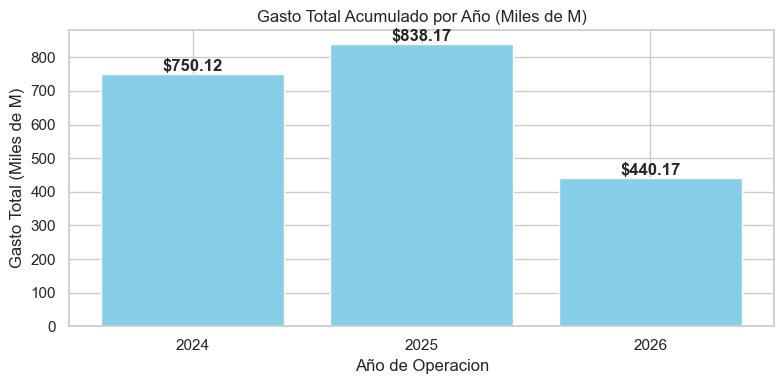

In [22]:
# ANÁLISIS EXPLORATORIO VISUAL (EDA)

# Cargar el archivo consolidado
df_consolidado = pd.read_csv(os.path.join(ruta_carpeta, "gastos_consolidados_limpios.csv"))

# Mostrar números normales formateados
pd.options.display.float_format = '{:,.2f}'.format

# Resumen estadístico
print("Resumen estadistico del gasto neto (Transacciones individuales):")
display(df_consolidado[['NETO', 'as_movano', 'as_movmes']].describe())

# Agrupar el gasto total por año (en miles)
df_gasto_anual = df_consolidado.groupby('as_movano')['NETO'].sum().reset_index()
df_gasto_anual['Gasto_Miles_Millones'] = df_gasto_anual['NETO'] / 1e9

# Gráfica de Barras: Comparativo de Gasto Acumulado por Año
plt.figure(figsize=(8, 4))
bars = plt.bar(df_gasto_anual['as_movano'].astype(str), df_gasto_anual['Gasto_Miles_Millones'], color='skyblue')

# Etiquetas de valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"${yval:,.2f}", ha='center', va='bottom', fontweight='bold')

plt.title("Gasto Total Acumulado por Año (Miles de M)")
plt.xlabel("Año de Operacion")
plt.ylabel("Gasto Total (Miles de M)")
plt.tight_layout()
plt.show()

El resumen estadístico permitió identificar que la variable objetivo presenta una distribución muy dispersa y con valores extremos, algo común en datos financieros. Conocer este comportamiento es importante para seleccionar métricas de evaluación como MAE, RMSE y MAPE, que permiten medir adecuadamente el error de predicción.

La gráfica de Gasto Total Acumulado Muestra la magnitud operativa de la compañía y confirma una tendencia de crecimiento constante. Validar este volumen a mano fila por fila en cada cierre consume mucho tiempo.

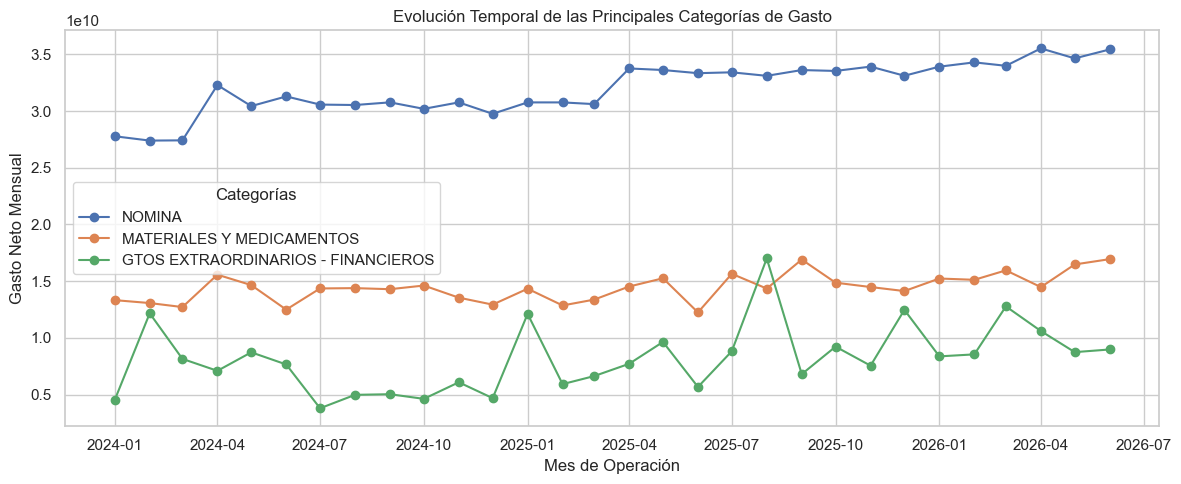

In [23]:
# Agrupar el gasto neto de forma mensual
df_mensual = df_consolidado.groupby(['as_movano', 'as_movmes', 'GR'], as_index=False)['NETO'].sum()
df_mensual['Fecha'] = pd.to_datetime(df_mensual['as_movano'].astype(str) + '-' + df_mensual['as_movmes'].astype(str) + '-01')

# Categorías con mayor gasto acumulado
top_categorias = df_mensual.groupby('GR')['NETO'].sum().nlargest(3).index

# Gráfica de tendencias
plt.figure(figsize=(12, 5))
for cat in top_categorias:
    df_cat = df_mensual[df_mensual['GR'] == cat].sort_values('Fecha')
    plt.plot(df_cat['Fecha'], df_cat['NETO'], marker='o', label=cat)
    
plt.title("Evolución Temporal de las Principales Categorías de Gasto")
plt.xlabel("Mes de Operación")
plt.ylabel("Gasto Neto Mensual")
plt.legend(title="Categorías")
plt.tight_layout()
plt.show()

Esta gráfica muestra la evolución mensual de las 3 categorías con mayor peso financiero: NÓMINA, MATERIALES Y MEDICAMENTOS y GASTOS EXTRAORDINARIOS - FINANCIEROS.

# BLOQUE 2: Preprocesamiento de Datos

In [24]:
# CONSTRUCCIÓN DE VARIABLES PREDICTORAS

# Agrupar el gasto neto mensual histórico por Año, Mes y Grupo de Gasto (GR)
df_caracteristicas = df_consolidado.groupby(['as_movano', 'as_movmes', 'GR'], as_index=False)['NETO'].sum()

# Ordenar cronológicamente por categoría para garantizar el orden secuencial
df_caracteristicas = df_caracteristicas.sort_values(by=['GR', 'as_movano', 'as_movmes']).reset_index(drop=True)

# Definición de variables predictoras basadas en el historial (Lags)

# 1. Gasto del mes inmediatamente anterior (Lag 1)
df_caracteristicas['Gasto_Lag_1'] = df_caracteristicas.groupby('GR')['NETO'].shift(1)

# 2. Gasto de hace dos meses (Lag 2)
df_caracteristicas['Gasto_Lag_2'] = df_caracteristicas.groupby('GR')['NETO'].shift(2)

# 3. Promedio móvil de los últimos 2 meses (Tendencia a corto plazo)
df_caracteristicas['Promedio_Movil_2M'] = df_caracteristicas.groupby('GR')['NETO'].shift(1).rolling(window=2, min_periods=1).mean()

# Eliminar las filas iniciales que quedan vacías (NaN) debido a los desplazamientos temporales que se generaron al crear los Lags
df_caracteristicas = df_caracteristicas.dropna().reset_index(drop=True)

# Guardar la matriz resultante
ruta_matriz_gastos = os.path.join(ruta_carpeta, "matriz_de_gastos.csv")
df_caracteristicas.to_csv(ruta_matriz_gastos, index=False, encoding='utf-8-sig')

print(f"Total de registros estructurados: {df_caracteristicas.shape[0]} filas.")
print("MATRIZ DE GASTOS PREPARADA PARA EL MODELADO")
df_caracteristicas[['as_movano', 'as_movmes', 'GR', 'Gasto_Lag_1', 'Gasto_Lag_2', 'Promedio_Movil_2M', 'NETO']].head()

Total de registros estructurados: 1095 filas.
MATRIZ DE GASTOS PREPARADA PARA EL MODELADO


,as_movano,as_movmes,GR,Gasto_Lag_1,Gasto_Lag_2,Promedio_Movil_2M,NETO
0,2024,3,ACUEDUCTO,"92,327,462.00","40,128,319.00","66,227,890.50","65,768,540.00"
1,2024,4,ACUEDUCTO,"65,768,540.00","92,327,462.00","79,048,001.00","72,629,187.00"
2,2024,5,ACUEDUCTO,"72,629,187.00","65,768,540.00","69,198,863.50","59,649,026.00"
3,2024,6,ACUEDUCTO,"59,649,026.00","72,629,187.00","66,139,106.50","58,295,773.00"
4,2024,7,ACUEDUCTO,"58,295,773.00","59,649,026.00","58,972,399.50","58,483,562.00"


Para construir la "línea base" del presupuesto estimado para el mes de cierre, se generó una matriz de características basada en la historia de cada categoría o (GR)

In [25]:
# DIVISIÓN DE DATOS POR CRITERIO TEMPORAL (ENTRENAMIENTO / EVALUACIÓN)

# Definir cuáles serán nuestras variables predictoras (X) y la variable objetivo (y)
variables_X = ['as_movmes', 'Gasto_Lag_1', 'Gasto_Lag_2', 'Promedio_Movil_2M']
variable_y = 'NETO'

# Segmentación temporal: Entrenamiento (2024-2025) y Evaluación (2026)
fiel_entrenamiento = df_caracteristicas['as_movano'] < 2026
fiel_evaluacion = df_caracteristicas['as_movano'] == 2026

# Crear las matrices de características y vectores objetivo correspondientes
X_train = df_caracteristicas[fiel_entrenamiento][variables_X]
y_train = df_caracteristicas[fiel_entrenamiento][variable_y]

X_test = df_caracteristicas[fiel_evaluacion][variables_X]
y_test = df_caracteristicas[fiel_evaluacion][variable_y]

# Escalar las variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Variables escaladas correctamente utilizando StandardScaler.")

# Guardar los grupos de categorías (GR) correspondientes al 2026 para la fase de alertas finales
gr_test = df_caracteristicas[fiel_evaluacion]['GR'].values
mes_test = df_caracteristicas[fiel_evaluacion]['as_movmes'].values

# Crear tabla de resumen para la división temporal de datos

print("RESUMEN DE LA DIVISIÓN TEMPORAL DE DATOS")
df_resumen_division = pd.DataFrame({
    'Conjunto de Datos': ['Entrenamiento (Train)', 'Evaluación (Test)'],
    'Periodo Temporal': ['2024 - 2025', 'Año 2026'],
    'Cantidad de Registros': [X_train.shape[0], X_test.shape[0]],
    'Porcentaje (%)': [
        f"{(X_train.shape[0] / (X_train.shape[0] + X_test.shape[0])) * 100:.1f}%",
        f"{(X_test.shape[0] / (X_train.shape[0] + X_test.shape[0])) * 100:.1f}%"
    ]
})

display(df_resumen_division)

Variables escaladas correctamente utilizando StandardScaler.
RESUMEN DE LA DIVISIÓN TEMPORAL DE DATOS


,Conjunto de Datos,Periodo Temporal,Cantidad de Registros,Porcentaje (%)
0,Entrenamiento (Train),2024 - 2025,863,78.8%
1,Evaluación (Test),Año 2026,232,21.2%


La división del conjunto de datos se realizó respetando el orden cronológico, el modelo aprende con los dos años históricos completos (2024-2025) y evalúa su capacidad predictiva intentando estimar el comportamiento presupuestal del periodo actual (2026).

# BLOQUE 3: Entrenamiento y Modelado

In [26]:
# ENTRENAMIENTO Y MODELADO CONTRA EL AÑO 2026

# Calcular MAPE (evita divisiones por cero)
def calcular_mape_seguro(y_true, y_pred):
    mask = y_true != 0  
    if mask.sum() == 0:
        return 0.0
    return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100

# Inicializar los tres modelos
modelo_lr = LinearRegression()
modelo_dt = DecisionTreeRegressor(random_state=42, max_depth=5)
modelo_rf = RandomForestRegressor(random_state=42, n_estimators=100)

# Entrenar los modelos utilizando los datos escalados (2024-2025)
modelo_lr.fit(X_train_scaled, y_train)
modelo_dt.fit(X_train_scaled, y_train)
modelo_rf.fit(X_train_scaled, y_train)

# Predicciones sobre el periodo de evaluación (2026)
pred_lr = modelo_lr.predict(X_test_scaled)
pred_dt = modelo_dt.predict(X_test_scaled)
pred_rf = modelo_rf.predict(X_test_scaled)

# Tabla con métricas
metricas = {
    "Regresión Lineal": {
        "R2 Score": r2_score(y_test, pred_lr),
        "RMSE ($)": np.sqrt(mean_squared_error(y_test, pred_lr)),
        "MAE ($)": mean_absolute_error(y_test, pred_lr),
        "MAPE (%)": calcular_mape_seguro(y_test.values, pred_lr)
    },
    "Árbol de Decisión": {
        "R2 Score": r2_score(y_test, pred_dt),
        "RMSE ($)": np.sqrt(mean_squared_error(y_test, pred_dt)),
        "MAE ($)": mean_absolute_error(y_test, pred_dt),
        "MAPE (%)": calcular_mape_seguro(y_test.values, pred_dt)
    },
    "Random Forest": {
        "R2 Score": r2_score(y_test, pred_rf),
        "RMSE ($)": np.sqrt(mean_squared_error(y_test, pred_rf)),
        "MAE ($)": mean_absolute_error(y_test, pred_rf),
        "MAPE (%)": calcular_mape_seguro(y_test.values, pred_rf)
    }
}

# Tabla comparativa
df_metricas = pd.DataFrame(metricas).T
df_metricas_fmt = df_metricas.copy()

# Formato visual para la tabla
df_metricas_fmt['R2 Score'] = df_metricas_fmt['R2 Score'].map('{:.4f}'.format)
df_metricas_fmt['RMSE ($)'] = df_metricas_fmt['RMSE ($)'].map('${:,.2f}'.format)
df_metricas_fmt['MAE ($)'] = df_metricas_fmt['MAE ($)'].map('${:,.2f}'.format)
df_metricas_fmt['MAPE (%)'] = df_metricas_fmt['MAPE (%)'].map('{:.2f}%'.format)

print("TABLA COMPARATIVA DE RENDIMIENTO DE LOS MODELOS (TEST 2026)")
display(df_metricas_fmt)

TABLA COMPARATIVA DE RENDIMIENTO DE LOS MODELOS (TEST 2026)


,R2 Score,RMSE ($),MAE ($),MAPE (%)
Regresión Lineal,0.9946,"$444,805,732.99","$148,882,826.24",74.87%
Árbol de Decisión,0.9788,"$880,809,989.55","$254,345,880.95",52.10%
Random Forest,0.9888,"$639,564,731.30","$201,966,806.15",27.68%


La comparación del rendimiento muestra que la Regresión Lineal obtuvo el mejor rendimiento general, alcanzando el mayor R² (0.9946) y los menores valores de RMSE ($444,8 millones) y MAE ($148,9 millones), lo que indica que explicó mejor la variabilidad de los datos y presentó el menor error promedio en sus predicciones.

In [27]:
# EVALUACIÓN DEL % DE VARIACIÓN DEL RMSE EN LOS 3 MODELOS

# Gasto total del periodo de evaluación (2026) usando y_test
gasto_total_2026 = y_test.sum()

print("PORCENTAJE DE VARIACIÓN DEL RMSE FRENTE AL GASTO TOTAL 2026:\n")

for modelo in df_metricas.index:
    rmse_val = df_metricas.loc[modelo, 'RMSE ($)']
    pct_variacion = (rmse_val / gasto_total_2026) * 100
    print(f"• {modelo}:")
    print(f"  - RMSE: ${rmse_val:,.2f}")
    print(f"  - Variación respecto al gasto total: {pct_variacion:.2f}%\n")

PORCENTAJE DE VARIACIÓN DEL RMSE FRENTE AL GASTO TOTAL 2026:

• Regresión Lineal:
  - RMSE: $444,805,732.99
  - Variación respecto al gasto total: 0.10%

• Árbol de Decisión:
  - RMSE: $880,809,989.55
  - Variación respecto al gasto total: 0.20%

• Random Forest:
  - RMSE: $639,564,731.30
  - Variación respecto al gasto total: 0.15%



La Regresión Lineal demostró ser el mejor modelo. Su error cuadrático medio RMSE representa únicamente el 0.10% del total del gasto en 2026.

In [28]:
# COMPARACIÓN PREDICCIONES VS DATOS REALES

from IPython.display import display

# DataFrame de comparación usando las variables directamente
comparacion = pd.DataFrame({
    'Mes': mes_test,
    'Categoría': gr_test,
    'Valor Real': y_test,
    'Regresión Lineal': pred_lr,
    'Árbol de Decisión': pred_dt,
    'Random Forest': pred_rf
})

# Formato de moneda ($) limpio para que no salga en notación científica
columnas_dinero = ['Valor Real', 'Regresión Lineal', 'Árbol de Decisión', 'Random Forest']
comparacion_formateada = comparacion.copy()

for col in columnas_dinero:
    comparacion_formateada[col] = comparacion_formateada[col].map('${:,.2f}'.format)

# Mostrar las primeras 10 observaciones
print("COMPARATIVO DE PREDICCIONES FRENTE A VALORES REALES (2026)")
display(comparacion_formateada.head(10))

COMPARATIVO DE PREDICCIONES FRENTE A VALORES REALES (2026)


,Mes,Categoría,Valor Real,Regresión Lineal,Árbol de Decisión,Random Forest
22,1,ACUEDUCTO,"$66,575,795.00","$111,574,777.03","$108,119,111.55","$75,241,424.55"
23,2,ACUEDUCTO,"$66,797,145.00","$106,967,932.65","$108,119,111.55","$147,900,995.81"
24,3,ACUEDUCTO,"$62,399,348.00","$100,825,035.49","$108,119,111.55","$118,079,259.91"
25,4,ACUEDUCTO,"$71,039,244.00","$92,857,946.59","$108,119,111.55","$361,629,813.27"
26,5,ACUEDUCTO,"$71,271,285.00","$89,085,631.66","$108,119,111.55","$66,309,257.01"
27,6,ACUEDUCTO,"$82,118,439.00","$87,694,855.26","$108,119,111.55","$71,507,065.67"
50,1,ALCANTARILLADO,"$60,075,042.00","$104,281,156.71","$30,310,105.59","$63,571,117.91"
51,2,ALCANTARILLADO,"$60,136,101.00","$99,987,287.20","$30,310,105.59","$63,667,815.96"
52,3,ALCANTARILLADO,"$55,781,987.00","$94,201,096.95","$30,310,105.59","$62,121,528.07"
53,4,ALCANTARILLADO,"$63,643,973.00","$86,174,830.99","$30,310,105.59","$58,131,897.52"


Esta tabla presenta una comparación entre los valores reales del año 2026 y las predicciones generadas por los tres modelos de regresión para cada categoría y mes. Este análisis permite evaluar de forma puntual el comportamiento de cada algoritmo y verificar qué tan cercanas son sus estimaciones respecto a los datos observados.

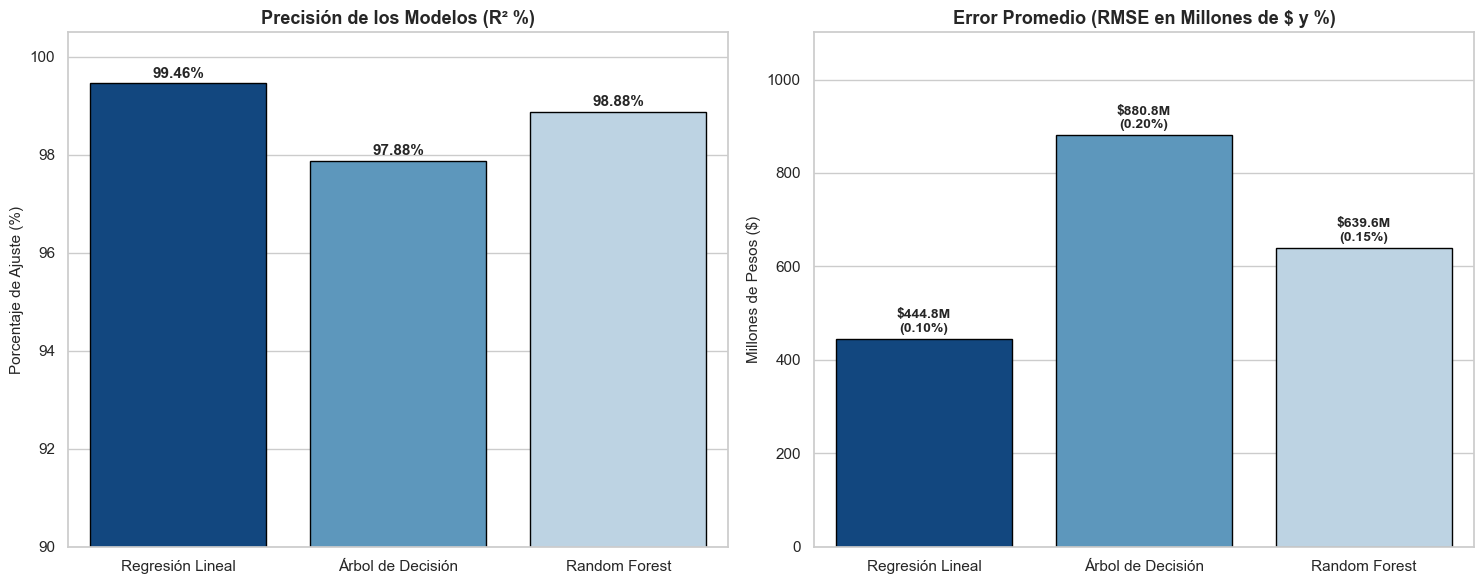

In [29]:
# GRÁFICA COMPARATIVA DE RENDIMIENTO DE LOS MODELOS

# Obtener datos
modelos = list(df_metricas.index)
r2_valores = [df_metricas.loc[m, 'R2 Score'] * 100 for m in modelos]

# Obtener RMSE en Pesos y calcular su % respecto al gasto total 2026 usando y_test
gasto_total_2026 = y_test.sum()
rmse_pesos = [df_metricas.loc[m, 'RMSE ($)'] for m in modelos]
rmse_pct = [(val / gasto_total_2026) * 100 for val in rmse_pesos]

# Generar la gráfica doble
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_style("whitegrid")
paleta = ['#004791', '#4D9BCC', '#B7D4E9']

# PANEL IZQUIERDO: PRECISIÓN DE LOS MODELOS (R² %)
barras1 = sns.barplot(ax=axes[0], x=modelos, y=r2_valores, palette=paleta, hue=modelos, legend=False, edgecolor='black')
axes[0].set_title("Precisión de los Modelos (R² %)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Porcentaje de Ajuste (%)", fontsize=11)
axes[0].set_ylim(90, 100.5)

# Anotar R² %
for i, p in enumerate(barras1.patches):
    barras1.annotate(f"{r2_valores[i]:.2f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 7),
                    textcoords='offset points', fontweight='bold', fontsize=11)

# PANEL DERECHO: ERROR PROMEDIO (RMSE EN $ Y %)
barras2 = sns.barplot(ax=axes[1], x=modelos, y=[val / 1e6 for val in rmse_pesos], palette=paleta, hue=modelos, legend=False, edgecolor='black')
axes[1].set_title("Error Promedio (RMSE en Millones de $ y %)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Millones de Pesos ($)", fontsize=11)
axes[1].set_ylim(0, max([val / 1e6 for val in rmse_pesos]) * 1.25)

# Anotar texto combinado: "$ XXX.XM \n (X.XX%)"
for i, p in enumerate(barras2.patches):
    monto_m = rmse_pesos[i] / 1e6
    pct = rmse_pct[i]
    texto_etiqueta = f"${monto_m:,.1f}M\n({pct:.2f}%)"

    barras2.annotate(texto_etiqueta,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 12),
                    textcoords='offset points', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

La gráfica compara el desempeño de los tres modelos utilizando dos métricas principales: R², que mide la capacidad del modelo para explicar la variación de los datos, y RMSE, que mide el error promedio de las predicciones.

Se observa que la Regresión Lineal obtuvo el mayor R² (99,46%) y el menor RMSE ($444,8 M), lo que indica que es el modelo más preciso y con el menor error de predicción.

In [30]:
# SELECCIÓN AUTOMÁTICA DEL MEJOR MODELO DE REGRESIÓN

# Predicciones y modelos evaluados
predicciones_modelos = {
    "Regresión Lineal": (modelo_lr, pred_lr),
    "Árbol de Decisión": (modelo_dt, pred_dt),
    "Random Forest": (modelo_rf, pred_rf)
}

# Identificar automáticamente cuál modelo obtuvo el menor RMSE
nombre_mejor_modelo = df_metricas['RMSE ($)'].idxmin()
mejor_modelo_objeto, mejor_prediccion = predicciones_modelos[nombre_mejor_modelo]

print(f"El modelo seleccionado automáticamente como MEJOR MODELO es: {nombre_mejor_modelo}")
print(f"R² Score: {df_metricas.loc[nombre_mejor_modelo, 'R2 Score']:.4f}")
print(f"RMSE: ${df_metricas.loc[nombre_mejor_modelo, 'RMSE ($)']:,.2f}")

El modelo seleccionado automáticamente como MEJOR MODELO es: Regresión Lineal
R² Score: 0.9946
RMSE: $444,805,732.99


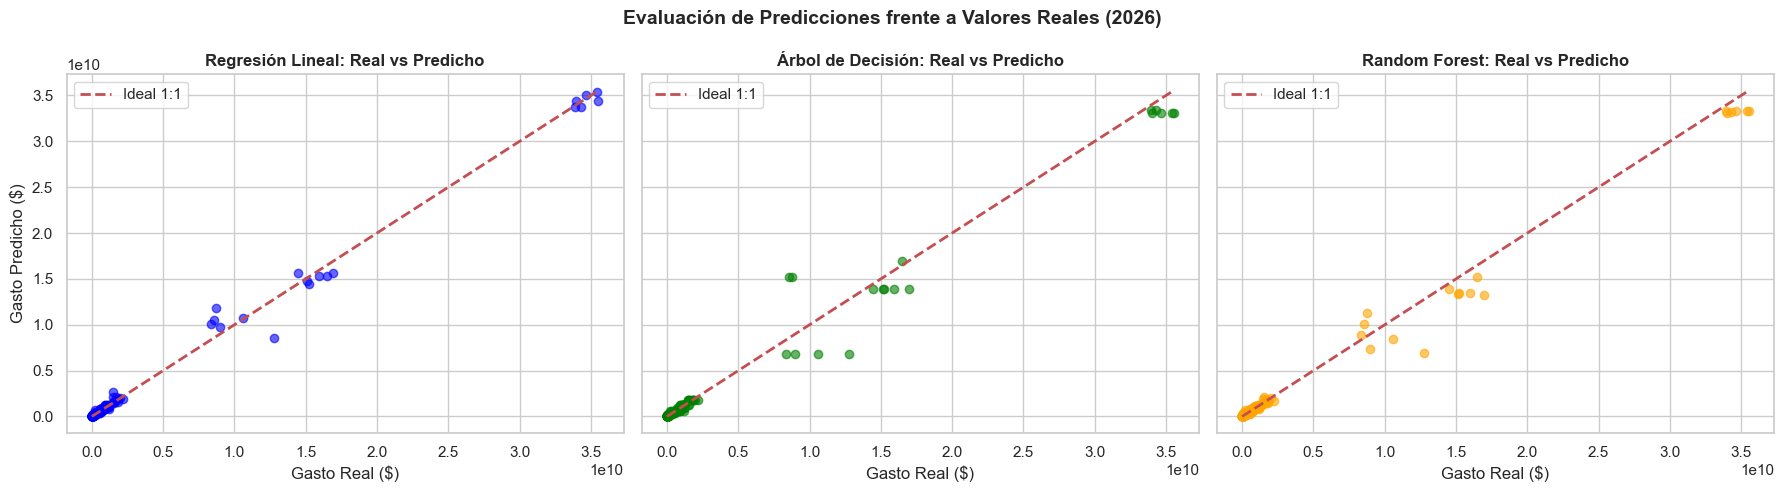

In [31]:
# GRÁFICA VALORES REALES VS PREDICHOS

# Crear una figura con 3 subgráficos (uno para cada modelo)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 1. Regresión Lineal
axes[0].scatter(y_test, pred_lr, color='blue', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1')
axes[0].set_title('Regresión Lineal: Real vs Predicho', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gasto Real ($)')
axes[0].set_ylabel('Gasto Predicho ($)')
axes[0].legend()

# 2. Árbol de Decisión
axes[1].scatter(y_test, pred_dt, color='green', alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1')
axes[1].set_title('Árbol de Decisión: Real vs Predicho', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gasto Real ($)')
axes[1].legend()

# 3. Random Forest
axes[2].scatter(y_test, pred_rf, color='orange', alpha=0.6)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1')
axes[2].set_title('Random Forest: Real vs Predicho', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Gasto Real ($)')
axes[2].legend()

plt.suptitle("Evaluación de Predicciones frente a Valores Reales (2026)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Esta gráfica compara los valores reales con los valores predichos por los tres modelos para el año 2026. La línea roja punteada representa la predicción ideal, donde el valor predicho es exactamente igual al valor real.

En la Regresión Lineal, los puntos azules se ciñen casi a la perfección sobre la diagonal. En los algoritmos basados en árboles se aprecian dispersiones en los rangos superiores.

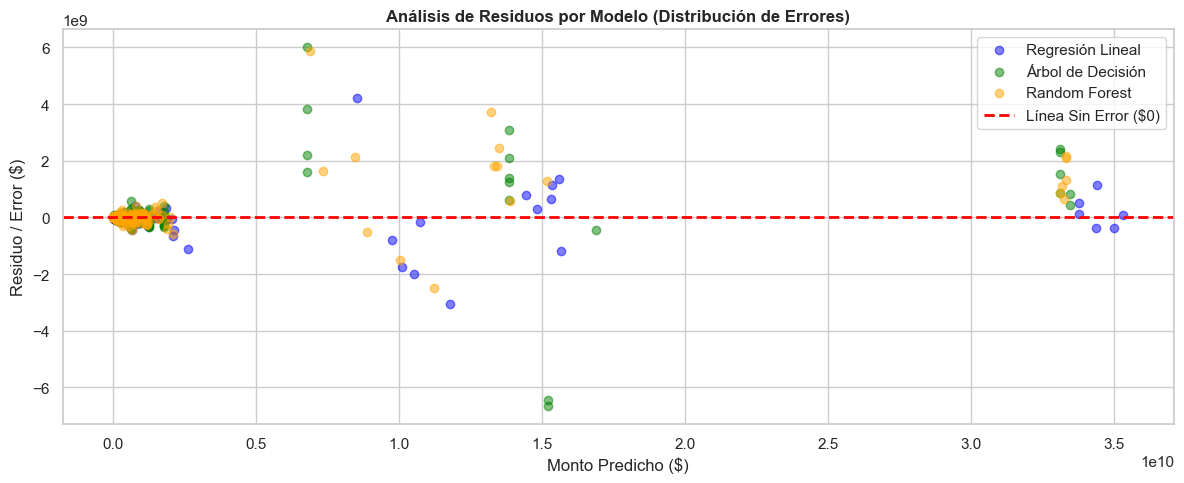

In [32]:
# GRÁFICA ANÁLISIS DE RESIDUOS (ERRORES DE ESTIMACIÓN)

# Calcular los residuos (Error = Valor Real - Valor Predicho)
residuos_lr = y_test - pred_lr
residuos_dt = y_test - pred_dt
residuos_rf = y_test - pred_rf

plt.figure(figsize=(12, 5))

# Graficar la dispersión de errores por cada modelo
plt.scatter(pred_lr, residuos_lr, color='blue', alpha=0.5, label='Regresión Lineal')
plt.scatter(pred_dt, residuos_dt, color='green', alpha=0.5, label='Árbol de Decisión')
plt.scatter(pred_rf, residuos_rf, color='orange', alpha=0.5, label='Random Forest')

# Línea de referencia en cero error
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Línea Sin Error ($0)')

plt.title("Análisis de Residuos por Modelo (Distribución de Errores)", fontsize=12, fontweight='bold')
plt.xlabel("Monto Predicho ($)")
plt.ylabel("Residuo / Error ($)")
plt.legend()
plt.tight_layout()
plt.show()

Esta gráfica muestra la distribución de los residuos (errores) de cada modelo, donde la línea roja representa el error cero. Un buen modelo debe tener la mayoría de sus errores cercanos a esta línea y distribuidos de forma aleatoria, sin un patrón definido.

# BLOQUE 4: Clasificación de gastos (recurrentes vs no recurrentes)  y alertas contables

REPORTE DE AUDITORIA PRESUPUESTAL 2026


,Mes,Categoria_GR,Gasto_Real,Gasto_Predicho,Porcentaje_Desviacion,Tipo_de_Gasto,Alerta_Auditoria
110,5,HONORARIOS NO MEDICOS,"1,189,704,401.00","778,720,917.83",52.78,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
96,3,GTOS EXTRAORDINARIOS - FINANCIEROS,"12,773,861,844.28","8,544,248,424.90",49.50,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
46,6,CAPACITACION,"106,332,613.00","75,025,268.99",41.73,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
168,3,OTROS LABORALES,"573,936,764.00","430,451,572.25",33.33,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
171,6,OTROS LABORALES,"470,513,364.00","354,791,397.89",32.62,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
175,4,PRORRATEO IVA,"658,515,228.00","505,076,411.91",30.38,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
102,3,HONORARIOS MEDICOS,"2,204,373,714.00","1,863,597,994.69",18.29,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
106,1,HONORARIOS NO MEDICOS,"957,802,503.00","830,314,460.95",15.35,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
100,1,HONORARIOS MEDICOS,"1,836,220,786.00","1,592,290,327.43",15.32,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)
11,6,ALCANTARILLADO,"90,302,431.00","78,403,921.40",15.18,GASTO NO RECURRENTE (Atipico),REVISAR (Anomalia Detectada)


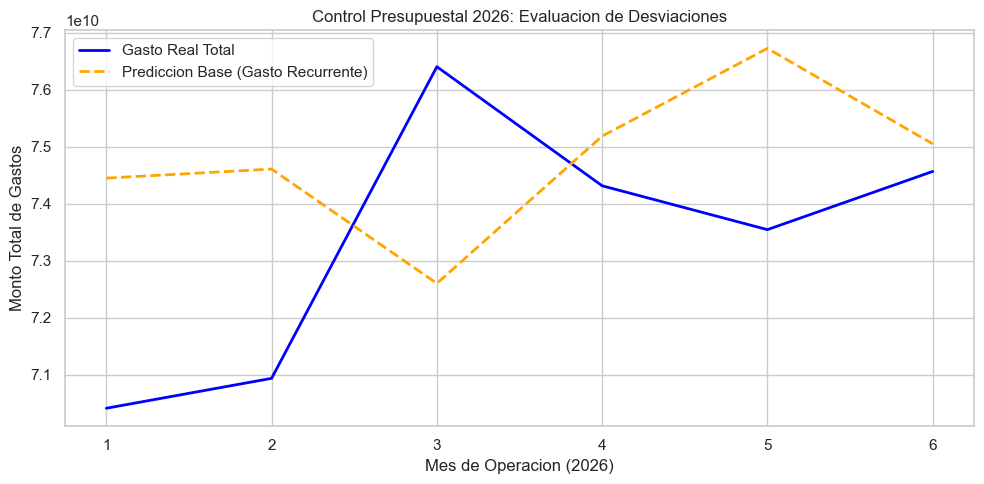

In [33]:
# Crear el DataFrame base unificando los datos reales de 2026 y las predicciones
df_resultados_2026 = pd.DataFrame({
    'Mes': mes_test,
    'Categoria_GR': gr_test,
    'Gasto_Real': y_test.values,
    'Gasto_Predicho': pred_lr  # Usamos la Regresión Lineal por ser el modelo ganador
})

# Calcular las desviaciones económicas
df_resultados_2026['Desviacion_Absoluta'] = df_resultados_2026['Gasto_Real'] - df_resultados_2026['Gasto_Predicho']
df_resultados_2026['Porcentaje_Desviacion'] = (df_resultados_2026['Desviacion_Absoluta'] / df_resultados_2026['Gasto_Predicho']) * 100

# CLASIFICACIÓN FINANCIERA: Recurrentes vs. No Recurrentes (Umbral de tolerancia = 10%)
df_resultados_2026['Tipo_de_Gasto'] = np.where(
    df_resultados_2026['Porcentaje_Desviacion'] > 10.0, 
    'GASTO NO RECURRENTE (Atipico)', 
    'GASTO RECURRENTE (Bajo Control)'
)

# Asignación del Estado de Alerta Contable
df_resultados_2026['Alerta_Auditoria'] = np.where(
    df_resultados_2026['Porcentaje_Desviacion'] > 10.0, 
    'REVISAR (Anomalia Detectada)', 
    'Aprobado (Dentro de Margen)'
)

# Reporte para la revisión 
from IPython.display import display

# Formato columnas a lo ancho
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("REPORTE DE AUDITORIA PRESUPUESTAL 2026")
columnas_reporte = ['Mes', 'Categoria_GR', 'Gasto_Real', 'Gasto_Predicho', 'Porcentaje_Desviacion', 'Tipo_de_Gasto', 'Alerta_Auditoria']

# Tabla Resumen
reporte_final = df_resultados_2026[columnas_reporte].sort_values(by='Porcentaje_Desviacion', ascending=False).head(15)
display(reporte_final)

# Gráfica del Control Presupuestal
df_totales_2026 = df_resultados_2026.groupby('Mes')[['Gasto_Real', 'Gasto_Predicho']].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(df_totales_2026['Mes'], df_totales_2026['Gasto_Real'], color='blue', linewidth=2, label='Gasto Real Total')
plt.plot(df_totales_2026['Mes'], df_totales_2026['Gasto_Predicho'], linestyle='--', color='orange', linewidth=2, label='Prediccion Base (Gasto Recurrente)')

plt.title("Control Presupuestal 2026: Evaluacion de Desviaciones")
plt.xlabel("Mes de Operacion (2026)")
plt.ylabel("Monto Total de Gastos")
plt.xticks(df_totales_2026['Mes'])
plt.legend()
plt.tight_layout()
plt.show()

Para cada registro se compara el Gasto Real con el Gasto Predicho, se calcula el Porcentaje de Desviación y, cuando esta diferencia supera el umbral definido, el sistema clasifica la transacción como "Gasto No Recurrente (Atípico)" y genera una alerta de auditoría para su revisión.

La gráfica Compara el gasto total ejecutado (Línea Azul) frente a la proyección base estimada (Línea Naranja) a lo largo de los meses de 2026.

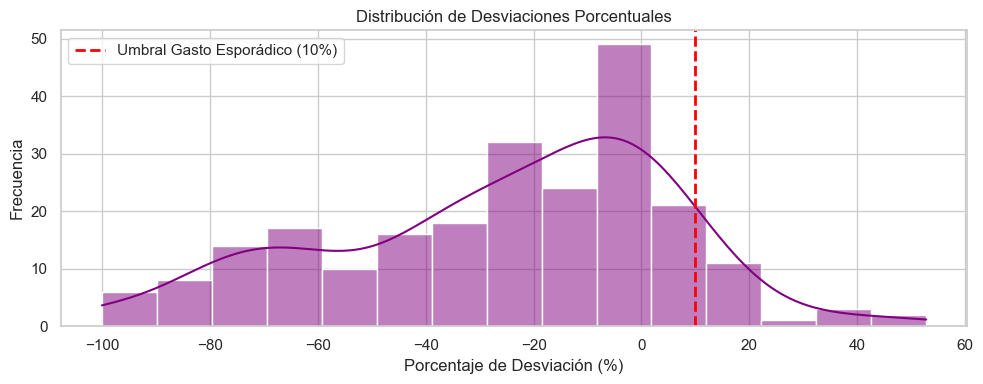

In [34]:
# GRÁFICA DISTRIBUCIÓN DE DESVIACIONES Y UMBRAL CONTABLE

plt.figure(figsize=(10, 4))
sns.histplot(df_resultados_2026['Porcentaje_Desviacion'], kde=True, color='purple', bins=15)
plt.axvline(x=10.0, color='red', linestyle='--', linewidth=2, label='Umbral Gasto Esporádico (10%)')

plt.title("Distribución de Desviaciones Porcentuales")
plt.xlabel("Porcentaje de Desviación (%)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

Esta gráfica muestra la distribución de las desviaciones porcentuales entre el gasto real y el gasto predicho por el modelo. La línea roja punteada representa el umbral del 10%, utilizado para identificar posibles gastos esporádicos o atípicos.

Se observa que la mayor parte de las desviaciones se concentra alrededor del 0%, lo que indica que el modelo predice correctamente la mayoría de los gastos recurrentes. Sin embargo, las desviaciones que superan el 10% son consideradas anomalías y se clasifican como gastos no recurrentes, ya que se alejan significativamente del comportamiento esperado.

# CONCLUSIONES

1. El análisis exploratorio permitió validar la calidad y consistencia del conjunto de datos, consolidando más de 295.000 registros correspondientes a los años 2024, 2025 y el primer semestre de 2026. La ausencia de valores nulos en las variables clave garantizó una base confiable para el entrenamiento de los modelos.

2. La decisión de conservar 52.443 transacciones con valores coincidentes respondió a un criterio de negocio propio del entorno contable, donde múltiples operaciones legítimas pueden registrar el mismo valor. Esto permitió preservar la representatividad del gasto real y evitar distorsiones en los montos utilizados para el entrenamiento del modelo.

3. La comparación de tres algoritmos de regresión permitió evaluar diferentes enfoques de aprendizaje automático e identificar, mediante métricas de desempeño, el modelo más adecuado para la predicción del gasto financiero.

4. La evaluación mostró que la Regresión Lineal fue el modelo con mejor rendimiento global, al obtener el mayor R² y los menores valores de RMSE y MAE, demostrando una mayor capacidad para explicar la variabilidad del gasto y generar predicciones más precisas. 

5. Las métricas de evaluación y las visualizaciones confirmaron que la Regresión Lineal produjo predicciones más cercanas a los valores reales, respaldando de manera objetiva su selección como modelo final. 

6. El análisis de residuos evidenció que los errores del modelo se concentraron alrededor de cero y sin patrones sistemáticos, indicando un comportamiento estable y una adecuada capacidad de generalización sobre los datos evaluados. 

7. El modelo seleccionado no solo permitió estimar el gasto esperado, sino también identificar desviaciones significativas entre el gasto real y el predicho, facilitando la detección de posibles gastos no recurrentes que requieren una revisión por parte del área financiera. 

8. La utilización de un umbral de desviación del 10% permitió generar alertas automáticas para aquellas transacciones que se apartan del comportamiento esperado, convirtiendo el modelo en una herramienta de apoyo para el proceso de auditoría y control presupuestal. 

9. Desde la perspectiva del negocio, el modelo desarrollado aporta valor al facilitar el seguimiento del comportamiento del gasto, apoyar la identificación temprana de desviaciones presupuestales y proporcionar información objetiva que contribuya a la toma de decisiones del área financiera.
